数据预览：
   temperature  time     effect
0          752    56  83.211730
1          920    95  82.095045
2          756    32  92.583462
3          721    75  86.607426
4          838    36  91.933156


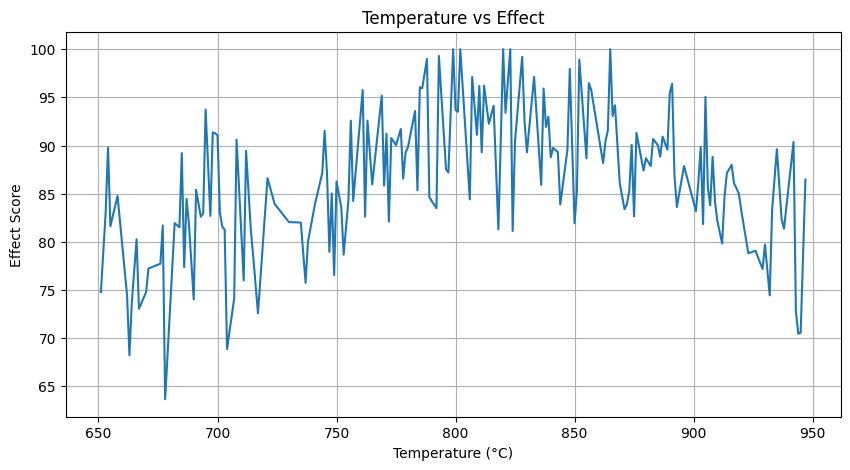

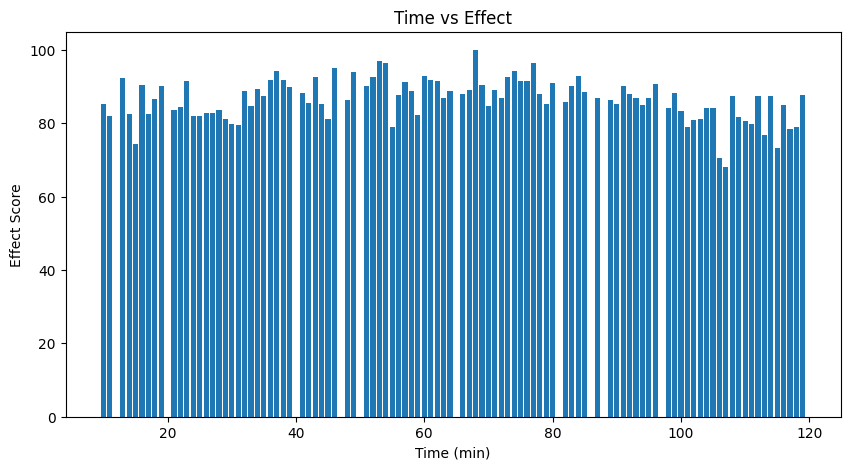

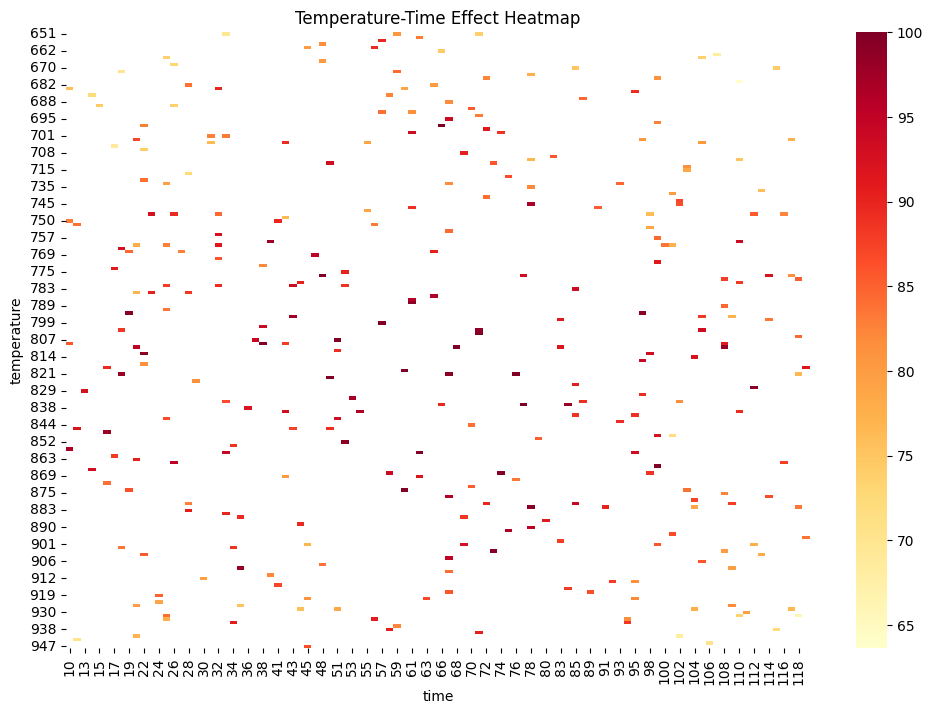

完成：数据 + 可视化生成成功


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1. 生成虚拟数据 ==========
np.random.seed(42)

n = 300

temperature = np.random.randint(650, 950, n)
time = np.random.randint(10, 120, n)

# 模拟“工艺效果评分”（核心逻辑：存在最优区间）
effect = (
    100
    - np.abs(temperature - 820) * 0.12
    - np.abs(time - 60) * 0.18
    + np.random.normal(0, 5, n)
)

effect = np.clip(effect, 40, 100)

df = pd.DataFrame({
    "temperature": temperature,
    "time": time,
    "effect": effect
})

print("数据预览：")
print(df.head())

# ========== 2. 温度 vs 效果 ==========
temp_group = df.groupby("temperature")["effect"].mean()

plt.figure(figsize=(10,5))
plt.plot(temp_group.index, temp_group.values)
plt.title("Temperature vs Effect")
plt.xlabel("Temperature (°C)")
plt.ylabel("Effect Score")
plt.grid()
plt.show()

# ========== 3. 时间 vs 效果 ==========
time_group = df.groupby("time")["effect"].mean()

plt.figure(figsize=(10,5))
plt.bar(time_group.index, time_group.values)
plt.title("Time vs Effect")
plt.xlabel("Time (min)")
plt.ylabel("Effect Score")
plt.show()

# ========== 4. 热力图 ==========
pivot = df.pivot_table(
    values="effect",
    index="temperature",
    columns="time",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Temperature-Time Effect Heatmap")
plt.show()

# ========== 5. 保存数据 ==========
df.to_csv("glass_fake_data.csv", index=False)

print("完成：数据 + 可视化生成成功")

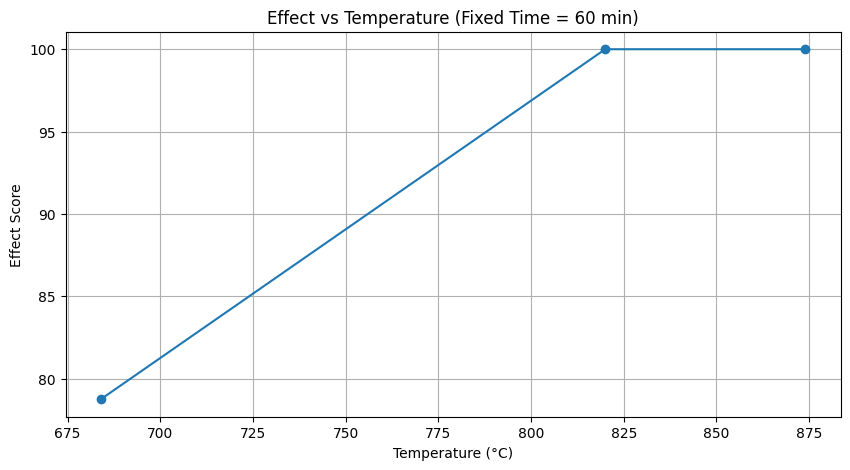

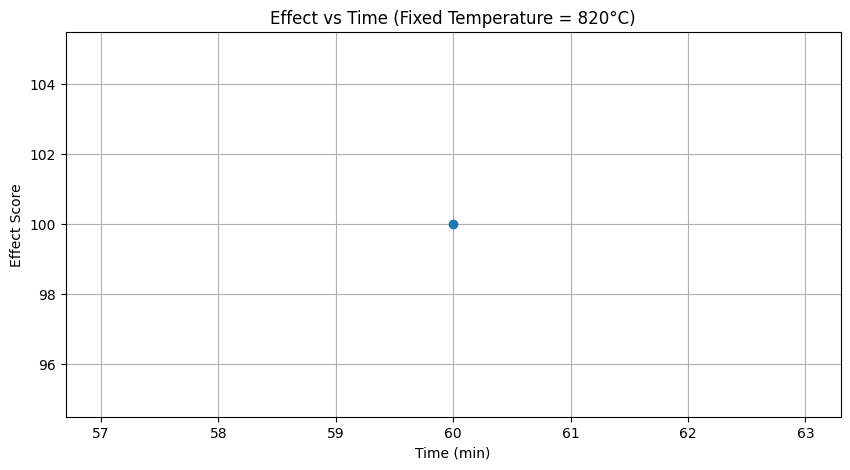

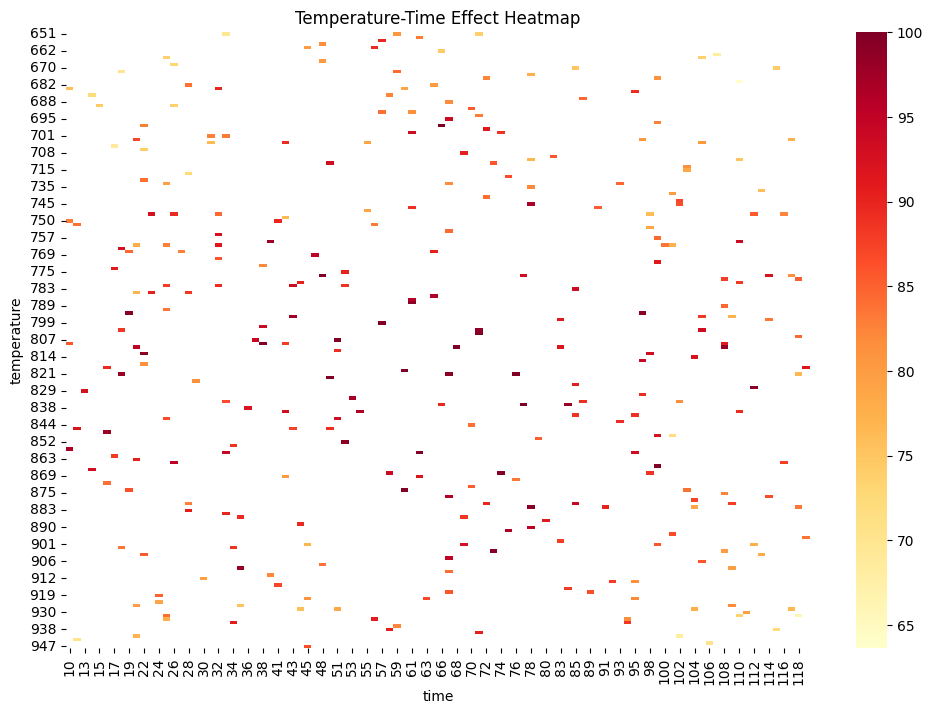

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. 如果你没有数据，就生成
# =========================
np.random.seed(42)

n = 300

df = pd.DataFrame({
    "temperature": np.random.randint(650, 950, n),
    "time": np.random.randint(10, 120, n)
})

df["effect"] = (
    100
    - abs(df["temperature"] - 820) * 0.12
    - abs(df["time"] - 60) * 0.18
    + np.random.normal(0, 5, n)
)

df["effect"] = np.clip(df["effect"], 40, 100)

# =====================================================
# ① 固定时间 → 不同温度对效果影响（控制变量分析）
# =====================================================

fixed_time = 60  # 你可以改成 30 / 90 观察变化

df_time_fixed = df[df["time"] == fixed_time]

temp_analysis = df_time_fixed.groupby("temperature")["effect"].mean()

plt.figure(figsize=(10,5))
plt.plot(temp_analysis.index, temp_analysis.values, marker='o')

plt.title(f"Effect vs Temperature (Fixed Time = {fixed_time} min)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Effect Score")
plt.grid()

plt.show()

# =====================================================
# ② 固定温度 → 不同时间对效果影响
# =====================================================

fixed_temp = 820  # 最优点附近（很关键）

df_temp_fixed = df[df["temperature"] == fixed_temp]

time_analysis = df_temp_fixed.groupby("time")["effect"].mean()

plt.figure(figsize=(10,5))
plt.plot(time_analysis.index, time_analysis.values, marker='o')

plt.title(f"Effect vs Time (Fixed Temperature = {fixed_temp}°C)")
plt.xlabel("Time (min)")
plt.ylabel("Effect Score")
plt.grid()

plt.show()

# =====================================================
# ③ 可选：二维热力图（增强版）
# =====================================================

pivot = df.pivot_table(
    values="effect",
    index="temperature",
    columns="time",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="YlOrRd")

plt.title("Temperature-Time Effect Heatmap")
plt.show()